나이 또는 연령대를 입력해주세요.


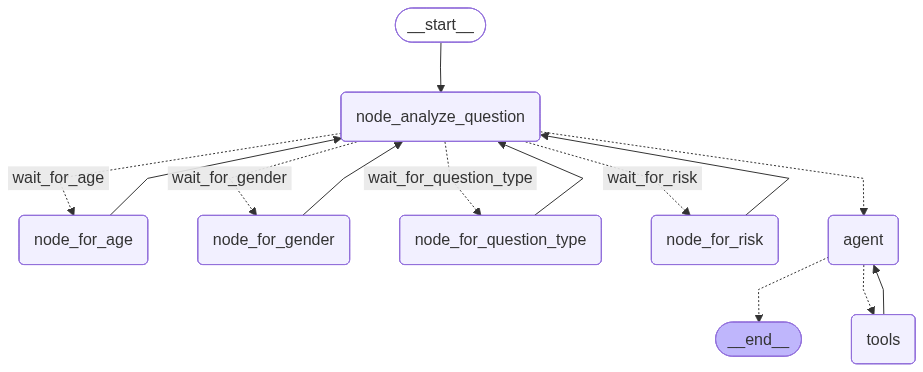

In [7]:
# ============================================================
# LangGraph 패키지 import
#StateGraph : Graph 구조를 설계
#MessagesState : 메시지 목록을 상태로 관리
#START : Graph의 시작 지점
#ToolNode : 모델이 요청한 Tool을 실제 실행
#tools_condition : Tool 호출 여부를 판단하여 분기
#SystemMessage : 시스템 지침 메시지
# ============================================================

from langchain_ollama import ChatOllama
from langchain.tools import tool
from langchain.messages import SystemMessage, HumanMessage

from langgraph.graph import StateGraph, START, END, MessagesState
from langgraph.prebuilt import ToolNode, tools_condition

#LangGraph 2단계: 모델과 Tool 정의 (LangChain과 거의 동일)

# ============================================================
# 모델 생성
# ============================================================

model = ChatOllama(
    model="qwen2.5:3b",
    base_url="http://localhost:11434",
    temperature=0.2,
)

# ============================================================
# Tool 정의
# ============================================================

@tool
def get_health_report(age: str, gender: str) -> str:
    """
    연령대와 성별에 따른 건강검진 정보를 제공한다.
    Args:
        age: 나이 또는 연령대
        gender: 성별
    """

    return (
        f"{age} {gender}의 건강검진 내용입니다. "
        f"혈압, 혈당, 콜레스테롤과 생활습관을 점검해야 합니다."
    )

#LangChain은 create_agent 생성할떄 tool을 매개변수로 넣었지만 LangGraph는 Tool 목록을 별도 변수로 만듭니다.
tools = [get_health_report]

#LangGraph 3단계: 모델에 Tool 연결

# ============================================================
# 모델에 Tool 목록 연결
# model_with_tools는 모델에게 아래의 정보를 전달 (실제로 tool을 실행하진 않음)
# - 사용 가능한 Tool 이름
# - Tool 설명
# - Tool 입력 인자
# - Tool 인자의 자료형
# ============================================================

model_with_tools = model.bind_tools(tools)

#Tool 실행 노드 작성

# ============================================================
# Tool 실행 노드
# ToolNode는 모델 응답의 tool_calls를 확인하여 실제 함수를 호출한 뒤 
# 그 결과를 TOOLMessage로 만들어서 State에 추가
# ============================================================

tool_node = ToolNode(tools)

#LangGraph 4단계: State 정의

# ============================================================
# State (모든 노드가 공유하는 메시지)
# ============================================================

# MessagesState를 직접 선언
from langgraph.graph import MessagesState
from typing_extensions import NotRequired

class HealthState(MessagesState):
    # 사용자 정보
    age_group: NotRequired[str]
    gender: NotRequired[str]
    # 질문 분석 정보
    question_type: NotRequired[str]
    # Tool 실행 결과 또는 부가 데이터
    health_report: NotRequired[str]
    # 위험도
    risk_level: NotRequired[str]
   
# ============================================================
# 질문 분석 결과 반환을 위한 딕셔너리 구조
# ============================================================
from typing_extensions import TypedDict

class QuestionAnalysis(TypedDict):
    """
    사용자 질문을 분석한 구조화 결과.
    """

    age_group: str
    gender: str
    question_type: str
    risk_level: str

#분석용 모델 객체 선언 모델질의 결과를 QuestionAnalysis 형태로 반환
analysis_model = model.with_structured_output(QuestionAnalysis)

#새로운 값이 들어올때 다른값들과 같이 들어오는게 아니라 입력된 값만 들어오므로 State의 이전값이 빈값으로 덮어씌워지는걸 막는 함수
#들어오는값이 없다면 이전값을 유지
def keep_existing(new_value, old_value):
    unknown_values = {
        None,
        "",
        "알 수 없음",
        "판단 불가",
    }

    if new_value in unknown_values:
        return old_value

    return new_value

#질문을 LLM이 QuestionAnalysis 구조에 맞춰 저장하는 함수
def node_analyze_question(state: HealthState) -> dict:
    """
    사용자 질문을 LLM으로 분석하여
    HealthState의 추가 필드값을 채운다.
    """

    # 가장 최근 사용자 질문을 찾는다.
    question = state["messages"][-1].content

    analysis_prompt = """
사용자의 건강 관련 질문을 분석하세요.

다음 필드를 반드시 채우세요.

- age_group:
  사용자의 연령대.
  예: 10대, 20대, 50대, 70대
  확인할 수 없으면 "알 수 없음"

- gender:
  사용자의 성별.
  예: 남성, 여성
  확인할 수 없으면 "알 수 없음"

- question_type:
  질문 유형.
  다음 중 하나를 선택:
  건강 주의사항, 건강검진, 질병 위험,
  증상 문의, 복약 문의, 일반 건강질문

- risk_level:
  질문 내용의 잠재적 긴급도.
  다음 중 하나를 선택:
  일반, 주의, 긴급, 판단 불가
""".strip()
    
    #LLM에게 작업 요청
    analysis = analysis_model.invoke(
        [
            {"role": "system", "content": analysis_prompt, },
            {"role": "user",  "content": str(question), },
        ]
    )

    return {
        "age_group": keep_existing(
            analysis.get("age_group"),
            state.get("age_group", "알 수 없음"),
        ),
        "gender": keep_existing(
            analysis.get("gender"),
            state.get("gender", "알 수 없음"),
        ),
        "question_type": keep_existing(
            analysis.get("question_type"),
            state.get("question_type", "알 수 없음"),
        ),
        "risk_level": keep_existing(
            analysis.get("risk_level"),
            state.get("risk_level", "알 수 없음"),
        ),
    }

#MessageState에 값이 없는경우 추가 입력받는 노드로 분기시키기위한 분기 노드
def node_route_after_analysis(state: HealthState) -> str:
    """
    분석 결과에서 알 수 없는 항목을 순서대로 확인하고
    필요한 추가 질문 노드로 이동한다.
    """

    if state.get("age_group", "알 수 없음") == "알 수 없음":
        return "wait_for_age"

    if state.get("gender", "알 수 없음") == "알 수 없음":
        return "wait_for_gender"

    if state.get("question_type", "알 수 없음") == "알 수 없음":
        return "wait_for_question_type"

    if state.get("risk_level", "판단 불가") == "판단 불가":
        return "wait_for_risk"

    return "agent"

#누락된 내용에 대한 추가질문 노드
from langchain.messages import AIMessage
from langgraph.types import interrupt
from langchain.messages import HumanMessage


def node_for_age(state: HealthState) -> dict:
    answer = interrupt(
        { 
             "message": "나이 또는 연령대를 입력해주세요.",
             "field": "age_group",
        }
    )
    return { "messages": [HumanMessage(content=str(answer))] }

def node_for_gender(state: HealthState) -> dict:
    answer = interrupt(
        {
            "message": "성별을 알려주세요. 예: 남성 또는 여성",
            "field": "gender",
        }
    )
    return { "messages": [HumanMessage(content=str(answer))]}


def node_for_question_type(state: HealthState) -> dict:
    answer = interrupt(
        {
            "message": (
                "어떤 건강정보를 원하시나요? "
                "예: 건강검진, 증상 문의, 복약 문의"
            ),
            "field": "question_type",
        }
    )
    return {"messages": [HumanMessage(content=str(answer))]}


def node_for_risk(state: HealthState) -> dict:
    answer = interrupt(
        {
            "message": (
                "현재 증상의 정도를 조금 더 설명해주세요. "
                "갑작스러운 통증, 호흡곤란, 의식 저하 등이 있나요?"
            ),
            "field": "risk_level",
        }
    )
    return {"messages": [HumanMessage(content=str(answer))]}

#모델 호출 노드 작성

# ============================================================
# LLM 호출 노드
# 모델이 Tool을 호출하고 싶다면 response에는 Tool 호출 정보가 들어갑니다.
# ============================================================

# ============================================================
# 시스템 프롬프트
# ============================================================

SYSTEM_PROMPT = """
건강 진단 및 질병예측에 대한 정보를 제공해야 합니다.

다음 원칙을 따르세요.

1. 사용자의 연령대와 성별을 확인하세요.
2. 연령대와 성별에 따른 정보가 필요하면
   get_health_report Tool을 호출하세요.
3. Tool 결과를 바탕으로 건강 주의사항을 설명하세요.
4. 의료적 확진은 하지 마세요.
5. 필요하면 의료기관 상담을 안내하세요.
""".strip()

def call_model(state: HealthState) -> dict:
    """
    현재까지 누적된 메시지를 모델에 전달한다.
    모델은 다음 중 하나를 반환한다.
    1. Tool 호출 요청
    2. 사용자에게 전달할 최종 답변
    """
    messages = [
        {"role": "system","content": SYSTEM_PROMPT,},
        *state["messages"],
    ]
    #전체 메시지들을 다시 모델에 전달해서 최종 답변을 할지 아니면 다시 TOOL을 호출할지 LLM이 결정
    response = model_with_tools.invoke(messages)
    # 새로 생성된 AIMessage를 State의 messages에 추가한다.
    return {
        "messages": [response]
    }



# Graph 생성
# ============================================================
# Graph 설계 객체 생성
# 노드왕 Edge를 등록하는 설계 객체
# ============================================================
#전체 노드가 공유할 State를 매개변수로 입력하여 객체 생성(MessageState를 사용해도됨)
graph_builder = StateGraph(HealthState)

# LangGraph 9단계: 노드 등록
# ============================================================
# 노드 등록
# ============================================================
# LLM 기반 질문 분석

graph_builder.add_node( "node_analyze_question", node_analyze_question,)
graph_builder.add_node( "node_for_age", node_for_age,)
graph_builder.add_node( "node_for_gender", node_for_gender,)
graph_builder.add_node( "node_for_question_type", node_for_question_type,)
graph_builder.add_node( "node_for_risk", node_for_risk,)
graph_builder.add_node( "agent", call_model,)
graph_builder.add_node( "tools", tool_node,)

#LangGraph 10단계: 시작 Edge 정의
# ============================================================
# 시작점 연결
# ============================================================
# 시작 → 질문 분석

graph_builder.add_edge(START, "node_analyze_question",)
graph_builder.add_conditional_edges(
    "node_analyze_question",
    node_route_after_analysis,
    {
        "wait_for_age": "node_for_age",
        "wait_for_gender": "node_for_gender",
        "wait_for_question_type": "node_for_question_type",
        "wait_for_risk": "node_for_risk",
        "agent": "agent",
    },
)

# 사용자 입력을 받은 후 다시 질문 분석
graph_builder.add_edge("node_for_age", "node_analyze_question")
graph_builder.add_edge("node_for_gender", "node_analyze_question")
graph_builder.add_edge("node_for_question_type", "node_analyze_question")
graph_builder.add_edge("node_for_risk", "node_analyze_question")

#LangGraph 11단계: 조건 분기 정의
# ============================================================
# Tool 호출 여부에 따른 조건 분기
# ============================================================

#graph_builder.add_conditional_edges( "agent", tools_condition,)
graph_builder.add_conditional_edges("agent",
    tools_condition,
    {
        "tools": "tools",
        "__end__": END,
    },
)

#LangGraph 12단계: Tool 실행 후 모델 재호출
# ============================================================
# Tool 실행 후 다시 Agent 노드로 이동
# ============================================================
# Agent → Tool 또는 종료

# Tool 실행 후 다시 Agent
graph_builder.add_edge("tools", "agent",)

#LangGraph 13단계: Graph 컴파일
# ============================================================
# Graph 컴파일
# ============================================================
from langgraph.checkpoint.memory import InMemorySaver

# ============================================================
# LangGraph Checkpointer 생성
# ============================================================
# InMemorySaver는 Graph 실행 중 생성되는 State와 중단 위치를
# 현재 Python 프로세스의 메모리에 저장한다.
#
# thread_id를 기준으로 다음 정보를 구분하여 저장한다.
# - 대화 메시지
# - 연령대, 성별 등 State 값
# - interrupt()가 발생한 실행 위치
# - 다음 API 요청에서 재개할 상태
#
# 메모리 기반이므로 Python 또는 Jupyter 커널을 종료하면
# 저장된 대화 상태도 함께 사라진다.
# 운영 환경에서는 PostgreSQL, Redis 등의 영속 저장 방식이 필요하다.
# ============================================================
checkpointer = InMemorySaver()


# ============================================================
# Graph 컴파일
# ============================================================
# graph_builder에 등록된 Node, Edge, Conditional Edge를 검증하고
# 실제로 invoke()할 수 있는 실행 가능한 Graph 객체를 생성한다.
#
# checkpointer를 지정하면 동일한 thread_id로 실행할 때
# 이전 State를 복원할 수 있다.
#
# interrupt()로 Graph가 중단된 경우에도 현재 State와 실행 위치가
# checkpointer에 저장되며, 이후 같은 thread_id와
# Command(resume=...)를 사용하여 중단 지점부터 이어서 실행할 수 있다.
# ============================================================
health_graph = graph_builder.compile(
    checkpointer=checkpointer,
)

#LangGraph 14단계: 실행 함수 작성
# ============================================================
# LangGraph 실행 함수
# ============================================================
from langgraph.types import Command
def health_query_graph(
    graph, 
    question: str,
    thread_id: str,
    resume: bool = False, ) -> dict:
    """
    사용자 질문을 LangGraph에 전달하고
    최종 State를 반환한다.
    """
    config = { "configurable": { "thread_id": thread_id, } }
    if resume:
        result = graph.invoke(
            Command(resume=question),
            config=config,
        )
    else:
        result = graph.invoke(
            {"messages": [HumanMessage(content=question)]},
            config=config,
        )
    return result
#============================================
#실행(첫번째 질문) : 필수 항목인 나이를 누락
#============================================
thread_id = "health-conversation-001"

result = health_query_graph(
    health_graph,
    "남성의 건강 주의사항 알려줘",
    thread_id=thread_id,
    resume=False,
)
interrupts = result.get("__interrupt__", [])
if interrupts:
    print(interrupts[0].value["message"])
else:
    print(result["messages"][-1].content)
health_graph

In [6]:
#============================================
#실행(두번째 질문) : 나이입력 후 답변확인
#============================================
result = health_query_graph(
    health_graph,
    "54살",
    thread_id=thread_id,
    resume=True,
)
interrupts = result.get("__interrupt__", [])
if interrupts:
    print(interrupts[0].value["message"])
else:
    print(result["messages"][-1].content)



남성 54세는 다음과 같은 주의사항이 필요합니다:

- 혈압, 혈당 및 콜레스테롤 수치를 정기적으로 검사하고 관리하세요.
- 건강한 식단과 규칙적인 운동을 유지하세요. 
- 흡연과 과도한 음酒 섭취는 피해야 합니다.
- 정기적인 체크업을 통해 건강 상태를 지속적으로 모니터링하세요.

의료 전문가와 상담해보시면 좋겠습니다.
